<a href="https://colab.research.google.com/github/aman70289/MLIntern-/blob/main/week_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## 1. Generate Synthetic Dataset for Clustering

First 5 rows of the generated dataset:


,Feature_1,Feature_2,True_Cluster
0,-8.668355,7.168180,3
1,-6.434370,-6.700534,2
2,-6.544631,-6.834506,2
3,4.364262,1.463263,1
4,4.484124,1.071284,1


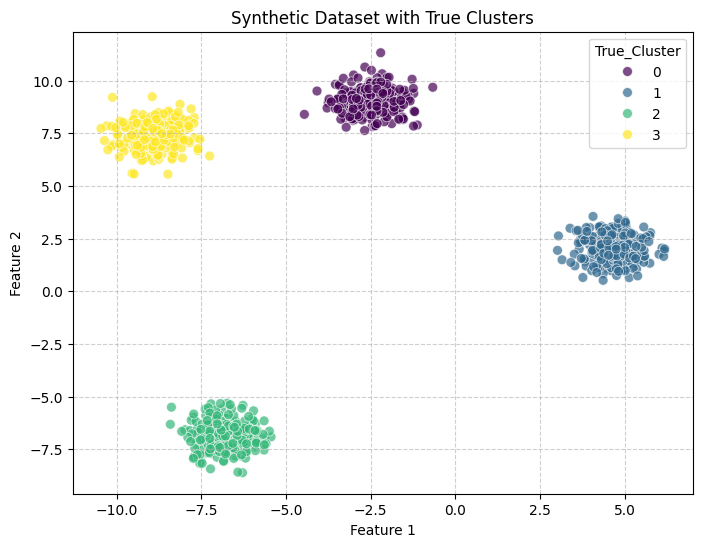

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import make_blobs

# Generate a synthetic dataset with 4 distinct clusters
X, y = make_blobs(n_samples=1000, centers=4, cluster_std=0.60, random_state=42)

# Create a DataFrame for better handling and visualization
df = pd.DataFrame(X, columns=['Feature_1', 'Feature_2'])
df['True_Cluster'] = y

print("First 5 rows of the generated dataset:")
display(df.head())

# Visualize the true clusters
plt.figure(figsize=(8, 6))
sns.scatterplot(x='Feature_1', y='Feature_2', hue='True_Cluster', data=df, palette='viridis', s=50, alpha=0.7)
plt.title('Synthetic Dataset with True Clusters')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

The `make_blobs` function is excellent for creating synthetic datasets that clearly show distinct clusters. Here, we've generated 1000 samples distributed among 4 centers, which will help us visualize how well different clustering algorithms perform.

## 2. Clustering Algorithms

### 2.1 K-Means Clustering

First 5 rows with K-Means assigned clusters:


,Feature_1,Feature_2,True_Cluster,KMeans_Cluster
0,-8.668355,7.168180,3,3
1,-6.434370,-6.700534,2,1
2,-6.544631,-6.834506,2,1
3,4.364262,1.463263,1,2
4,4.484124,1.071284,1,2


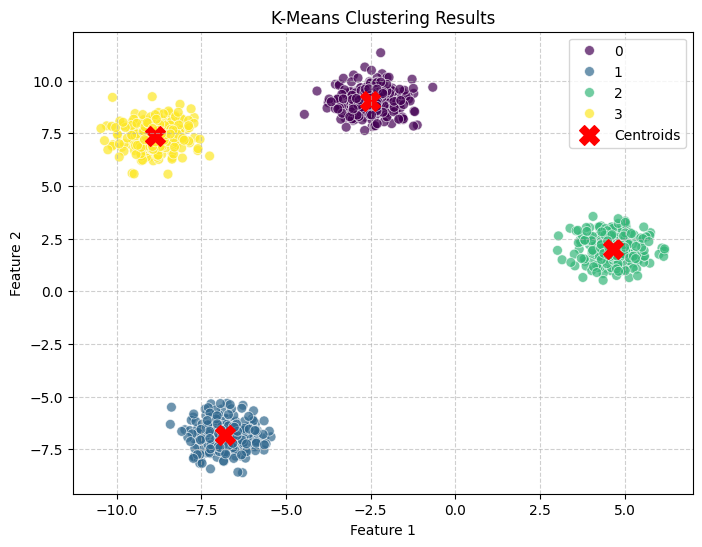

In [2]:
from sklearn.cluster import KMeans

# Apply K-Means with 4 clusters (since we know the true number of clusters)
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10) # n_init for robust centroid initialization
kmeans_labels = kmeans.fit_predict(X)

df['KMeans_Cluster'] = kmeans_labels

print("First 5 rows with K-Means assigned clusters:")
display(df.head())

# Visualize K-Means clusters
plt.figure(figsize=(8, 6))
sns.scatterplot(x='Feature_1', y='Feature_2', hue='KMeans_Cluster', data=df, palette='viridis', s=50, alpha=0.7)
plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1], s=200, c='red', marker='X', label='Centroids')
plt.title('K-Means Clustering Results')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.show()

K-Means is an iterative clustering algorithm that aims to partition `n` observations into `k` clusters in which each observation belongs to the cluster with the nearest mean (centroid). It's a popular and efficient algorithm, especially for large datasets. The `n_init=10` parameter ensures that the algorithm runs 10 times with different centroid seeds and chooses the best result, making it more robust.

### 2.2 Hierarchical Clustering

First 5 rows with Hierarchical assigned clusters:


,Feature_1,Feature_2,True_Cluster,KMeans_Cluster,Hierarchical_Cluster
0,-8.668355,7.168180,3,3,1
1,-6.434370,-6.700534,2,1,0
2,-6.544631,-6.834506,2,1,0
3,4.364262,1.463263,1,2,2
4,4.484124,1.071284,1,2,2


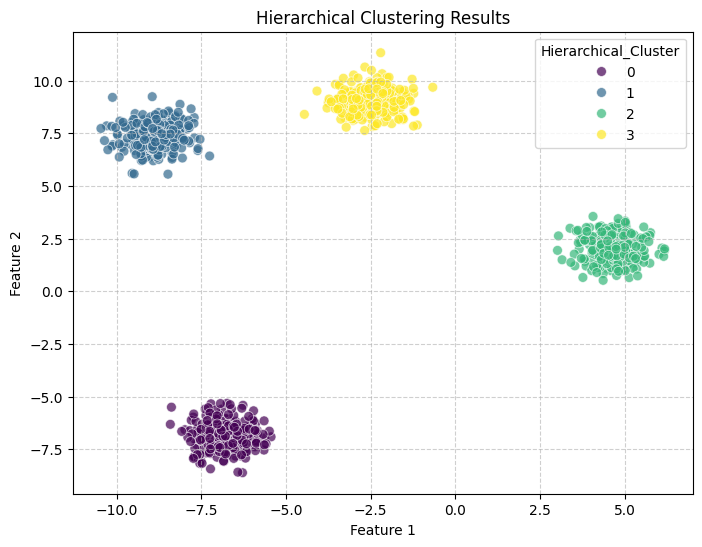

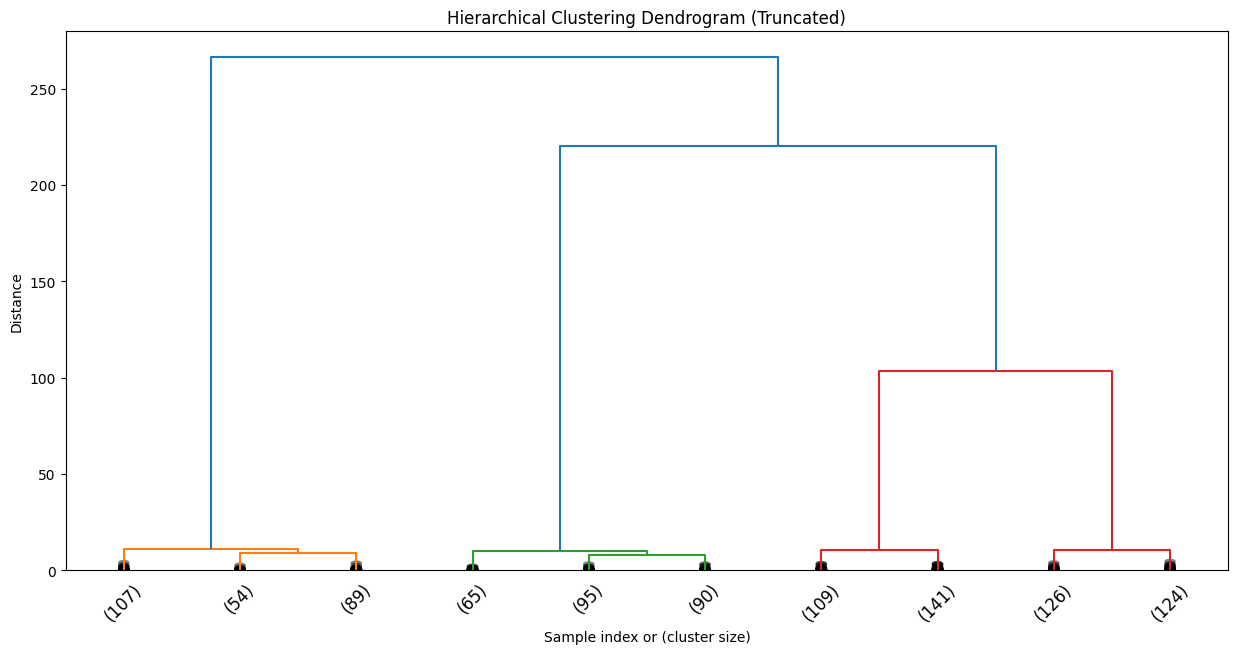

In [3]:
from sklearn.cluster import AgglomerativeClustering
from scipy.cluster.hierarchy import dendrogram, linkage

# Apply Hierarchical Clustering with 4 clusters
hierarchical = AgglomerativeClustering(n_clusters=4, linkage='ward') # 'ward' minimizes the variance within each cluster
hierarchical_labels = hierarchical.fit_predict(X)

df['Hierarchical_Cluster'] = hierarchical_labels

print("First 5 rows with Hierarchical assigned clusters:")
display(df.head())

# Visualize Hierarchical Clustering results
plt.figure(figsize=(8, 6))
sns.scatterplot(x='Feature_1', y='Feature_2', hue='Hierarchical_Cluster', data=df, palette='viridis', s=50, alpha=0.7)
plt.title('Hierarchical Clustering Results')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

# Visualize the dendrogram (for smaller datasets or a subset for demonstration)
# For larger datasets like this, plotting the full dendrogram can be computationally intensive and visually cluttered.
# We'll plot a truncated dendrogram to show structure.
linked_data = linkage(X, method='ward') # Perform hierarchical clustering

plt.figure(figsize=(15, 7))
dendrogram(
    linked_data,
    truncate_mode='lastp',  # show only the last p merged clusters
    p=10,  # show only the last 10 merges
    leaf_rotation=45.,
    leaf_font_size=12.,
    show_contracted=True,  # to get a feel for the original dataset size
)
plt.title('Hierarchical Clustering Dendrogram (Truncated)')
plt.xlabel('Sample index or (cluster size)')
plt.ylabel('Distance')
plt.show()

Hierarchical clustering builds a hierarchy of clusters. It starts with each data point as a single cluster and then merges or splits clusters based on a similarity measure. The dendrogram visually represents this hierarchy, showing how clusters are combined at different distance levels. The `linkage='ward'` method minimizes the total within-cluster variance.

## 3. Dimensionality Reduction Concepts

Dimensionality reduction is the process of reducing the number of random variables under consideration by obtaining a set of principal variables. It can be useful for visualization, noise reduction, and to help some algorithms perform better by reducing the 'curse of dimensionality'.

### Principal Component Analysis (PCA)
PCA is a popular technique for dimensionality reduction. It transforms the data into a new coordinate system such that the greatest variance by any projection of the data lies on the first coordinate (called the first principal component), the second greatest variance on the second coordinate, and so on. This effectively captures the most important information (variance) in fewer dimensions.

Explained variance ratio by each principal component:
[0.59210574 0.40789426]
Total explained variance: 1.00
First 5 rows of PCA transformed data:


,Principal_Component_1,Principal_Component_2,True_Cluster,KMeans_Cluster,Hierarchical_Cluster
0,3.468852,-5.850899,3,3,1
1,-9.932128,-1.638341,2,1,0
2,-10.080614,-1.728108,2,1,0
3,-0.295035,7.868734,1,2,2
4,-0.665607,8.043923,1,2,2


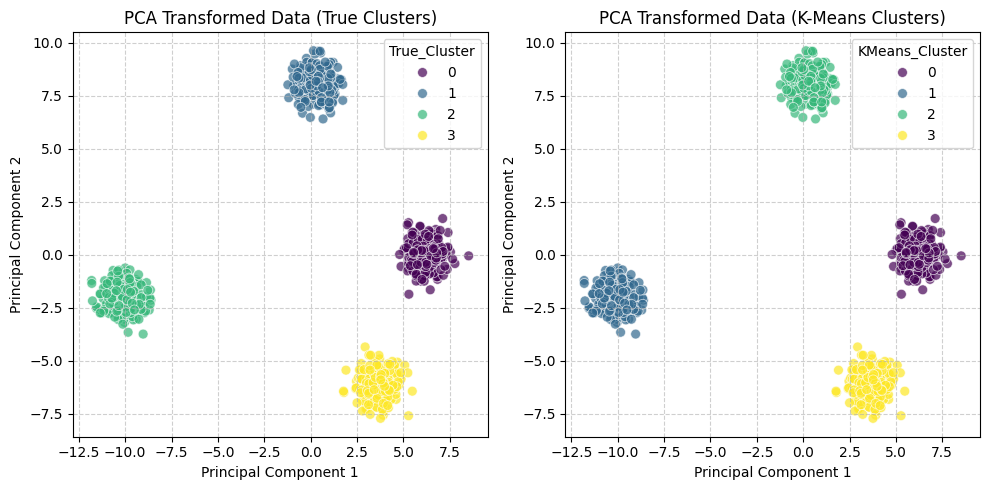

In [4]:
from sklearn.decomposition import PCA

# Initialize PCA to reduce to 2 components for visualization
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

# Create a DataFrame for PCA results
df_pca = pd.DataFrame(X_pca, columns=['Principal_Component_1', 'Principal_Component_2'])
df_pca['True_Cluster'] = y
df_pca['KMeans_Cluster'] = kmeans_labels
df_pca['Hierarchical_Cluster'] = hierarchical_labels

print("Explained variance ratio by each principal component:")
print(pca.explained_variance_ratio_)
print(f"Total explained variance: {pca.explained_variance_ratio_.sum():.2f}")

print("First 5 rows of PCA transformed data:")
display(df_pca.head())

# Visualize PCA transformed data with true clusters
plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
sns.scatterplot(x='Principal_Component_1', y='Principal_Component_2', hue='True_Cluster', data=df_pca, palette='viridis', s=50, alpha=0.7)
plt.title('PCA Transformed Data (True Clusters)')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.grid(True, linestyle='--', alpha=0.6)

plt.subplot(1, 2, 2)
sns.scatterplot(x='Principal_Component_1', y='Principal_Component_2', hue='KMeans_Cluster', data=df_pca, palette='viridis', s=50, alpha=0.7)
plt.title('PCA Transformed Data (K-Means Clusters)')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

## 4. Model Evaluation Report Concepts

For clustering (unsupervised learning), evaluation metrics are different from those used in supervised learning. Since we generated data with 'true' clusters, we can use metrics that compare predicted clusters against ground truth. However, in real-world scenarios without ground truth, intrinsic metrics are used.

### Clustering Evaluation Metrics

*   **Silhouette Score:** Measures how similar an object is to its own cluster compared to other clusters. A high Silhouette Score indicates well-separated clusters. The score ranges from -1 to 1, where a high value indicates that the object is well matched to its own cluster and poorly matched to neighboring clusters.
*   **Davies-Bouldin Index:** Measures the average similarity ratio between each cluster and its most similar cluster. A lower Davies-Bouldin index relates to a model with better separation between the clusters.
*   **Calinski-Harabasz Index (Variance Ratio Criterion):** Measures the ratio of the sum of between-clusters dispersion and within-cluster dispersion. Higher values correspond to a model with better-defined clusters.

Let's calculate the Silhouette Score for our K-Means and Hierarchical clustering results.

In [5]:
from sklearn.metrics import silhouette_score

# Evaluate K-Means
silhouette_avg_kmeans = silhouette_score(X, kmeans_labels)
print(f"Silhouette Score for K-Means: {silhouette_avg_kmeans:.3f}")

# Evaluate Hierarchical Clustering
silhouette_avg_hierarchical = silhouette_score(X, hierarchical_labels)
print(f"Silhouette Score for Hierarchical Clustering: {silhouette_avg_hierarchical:.3f}")

Silhouette Score for K-Means: 0.875
Silhouette Score for Hierarchical Clustering: 0.875


### Supervised Learning Evaluation Metrics (Conceptual Understanding)

The metrics you listed (cross-validation, confusion matrix, precision, recall, F1-score, ROC-AUC, hyperparameter tuning) are primarily used in **supervised learning**, where you have known target labels for prediction. While not directly applicable to our unsupervised clustering task for a 'deliverable report' in the same way, understanding them is crucial for any machine learning practitioner.

#### Cross-Validation

*   **Purpose:** To assess how the results of a statistical analysis (like training a model) generalize to an independent dataset. It helps to prevent overfitting and provides a more robust estimate of model performance.
*   **How it works (e.g., K-Fold Cross-Validation):** The dataset is split into `k` equally sized folds. The model is trained `k` times. In each iteration, one fold is used as the validation set, and the remaining `k-1` folds are used as the training set. The performance metrics are then averaged across all `k` iterations.

#### Confusion Matrix

*   **Purpose:** A table used to evaluate the performance of a classification model. It summarizes the number of correct and incorrect predictions made by a classifier compared to the actual outcomes.
*   **Components:**
    *   **True Positives (TP):** Correctly predicted positive class.
    *   **True Negatives (TN):** Correctly predicted negative class.
    *   **False Positives (FP):** Incorrectly predicted positive class (Type I error).
    *   **False Negatives (FN):** Incorrectly predicted negative class (Type II error).

#### Precision, Recall, F1-Score

These metrics are derived from the confusion matrix and are crucial for understanding a classifier's performance, especially in imbalanced datasets.

*   **Precision:** Of all predicted positive instances, how many were actually positive?
    $\text{Precision} = \frac{\text{TP}}{\text{TP} + \text{FP}}$
    High precision means fewer false positives.

*   **Recall (Sensitivity):** Of all actual positive instances, how many were correctly identified?
    $\text{Recall} = \frac{\text{TP}}{\text{TP} + \text{FN}}$
    High recall means fewer false negatives.

*   **F1-Score:** The harmonic mean of Precision and Recall. It provides a single score that balances both metrics, especially useful when there's an uneven class distribution.
    $\text{F1-Score} = 2 \times \frac{\text{Precision} \times \text{Recall}}{\text{Precision} + \text{Recall}}$

#### ROC-AUC (Receiver Operating Characteristic - Area Under the Curve)

*   **Purpose:** To evaluate the performance of a classification model across various threshold settings. It's particularly useful for binary classification problems.
*   **ROC Curve:** Plots the True Positive Rate (Recall) against the False Positive Rate ($\text{FPR} = \frac{\text{FP}}{\text{FP} + \text{TN}}$) at different threshold values. The diagonal line represents a random classifier.
*   **AUC Score:** The area under the ROC curve. A higher AUC (closer to 1) indicates a better performing model. An AUC of 0.5 suggests a classifier that performs no better than random guessing.

#### Hyperparameter Tuning

*   **Purpose:** To find the optimal set of hyperparameters for a machine learning model. Hyperparameters are parameters whose values are set before the learning process begins (e.g., `n_clusters` in K-Means, `learning_rate` in gradient boosting, `C` and `gamma` in SVMs).
*   **Methods:**
    *   **Grid Search:** Systematically works through multiple combinations of parameter tunes, cross-validating as it goes.
    *   **Random Search:** Randomly selects combinations of hyperparameters to try. Often more efficient than Grid Search for high-dimensional hyperparameter spaces.
    *   **Bayesian Optimization:** Uses probabilistic models to find the next best set of hyperparameters to evaluate, aiming to minimize the number of evaluations needed.